# StellarShift-Bench v1.2.3 - instant verified results

This notebook is useful **before any cell is run** because verified outputs are
embedded, and it is also fully runnable from the extracted source release. Its
data-loading cells read the archived LAMOST DR2 to DESI DR1 evidence. The same
harness also provides the controlled DESI S/N comparison.

Scientific status: real cross-survey optical transfer; 1,088 model-held-out DESI
evaluation stars; exact APOGEE DR12 ASPCAP v603 reference-label scale; object-
disjoint splits. The internal `feh` field contains APOGEE `PARAM_M_H` ([M/H]),
not elemental `FE_H`.


## Load the archived evidence


In [1]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import Image, display

working_directory = Path.cwd().resolve()
candidates = [working_directory, working_directory / "stellar-benchmark", *working_directory.parents]
ROOT = next(
    (
        candidate
        for candidate in candidates
        if (candidate / "results" / "lamost_dr2_to_desi_dr1_apogee_dr12").is_dir()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError(
        "Run this notebook from the extracted stellar-benchmark source release."
    )

CROSS = ROOT / "results" / "lamost_dr2_to_desi_dr1_apogee_dr12"
DESI = ROOT / "results" / "desi_reliability_v1"
FIGURES = ROOT / "output" / "figures"

gate = json.loads((CROSS / "publication_gate.json").read_text())
gate_table = pd.DataFrame(gate["criteria"])[
    ["criterion", "observed", "required", "passed"]
]
domain_shift = pd.read_csv(CROSS / "domain_shift_summary.csv")[[
    "target", "source_holdout_mae", "target_evaluation_mae",
    "cross_survey_mae_change_percent", "target_evaluation_r2",
]].round(3)
transfer_metrics = pd.read_csv(CROSS / "transfer_metrics.csv")
method_metrics = transfer_metrics.loc[
    transfer_metrics["evaluation"] == "target_evaluation_cross_survey",
    ["method", "target_access", "target", "mae", "r2", "mae_change_vs_source_percent"],
].round(3)
calibration_rows = pd.read_csv(CROSS / "calibration_cross_survey.csv")
calibration = calibration_rows[[
    "method", "calibration_source", "target", "coverage", "mean_width"
]].round(3)
support_rows = pd.read_csv(CROSS / "support_overlap_metrics.csv")
within_support = support_rows.loc[
    support_rows["method"] == "source_only",
    ["target", "supported_stars", "retained_fraction", "mae", "r2"],
].round(3)
effect_rows = pd.read_csv(CROSS / "adaptation_effect_intervals.csv")
paired_effects = effect_rows[[
    "method", "target", "paired_mae_difference", "paired_difference_ci_lower",
    "paired_difference_ci_upper", "conclusion",
]].round(3)
budget_rows = pd.read_csv(CROSS / "label_budget_trials.csv")
label_budget_medians = (
    budget_rows.groupby(["budget", "target"], as_index=False)["mae_change_vs_source_percent"]
    .median()
    .pivot(index="budget", columns="target", values="mae_change_vs_source_percent")
    .round(2)
)
reference_rows = pd.read_csv(CROSS / "reference_label_sensitivity.csv")
reference_sensitivity = reference_rows[[
    "method", "target", "sensitivity_difference_median",
    "sensitivity_difference_ci_lower", "sensitivity_difference_ci_upper",
    "fraction_difference_below_zero",
]].round(3)
ablation_rows = pd.read_csv(CROSS / "model_ablation.csv")
target_ablation = ablation_rows.loc[
    ablation_rows["evaluation"] == "target_evaluation_cross_survey",
    ["family", "target", "mae", "r2", "mae_change_vs_source_domain_percent"],
].round(3)
noise_rows = pd.read_csv(DESI / "nested_bootstrap_intervals.csv")
noise_2x = noise_rows.loc[
    (noise_rows["model"] == "source_only") & (noise_rows["noise_factor"] == 2.0),
    ["target", "clean_mae", "mae", "mae_change_percent", "change_ci_lower", "change_ci_upper"],
].round(3)

print(f"Loaded verified v1.2.3 evidence from {ROOT}")


Loaded verified v1.2.3 evidence


## Prespecified quality gate - passed before fitting


In [1]:
gate_table


                                    criterion                                                                                                        observed                                          required  passed
        shared_reference_label_scale_declared APOGEE_DR12_ASPCAP_v603_calibrated_TEFF_LOGG_PARAM_M_H | APOGEE_DR12_ASPCAP_v603_calibrated_TEFF_LOGG_PARAM_M_H same exact, version-pinned scale for both surveys    True
                           source_train_stars                                                                                                            1032                                              1000    True
                         source_holdout_stars                                                                                                             259                                               200    True
                      target_adaptation_stars                                                                                           

## Headline: real cross-survey shift is much larger than controlled noise

Source-only MAE roughly doubles for temperature and gravity and more than
triples for [M/H]. The earlier 2x-noise DESI result is retained as a descriptive
measurement-shift comparison, not a causal decomposition.


In [1]:
domain_shift


target  source_holdout_mae  target_evaluation_mae  cross_survey_mae_change_percent  target_evaluation_r2
  teff              52.499                109.415                          108.412                 0.656
  logg               0.124                  0.260                          110.035                 0.558
   feh               0.073                  0.250                          241.577                 0.220


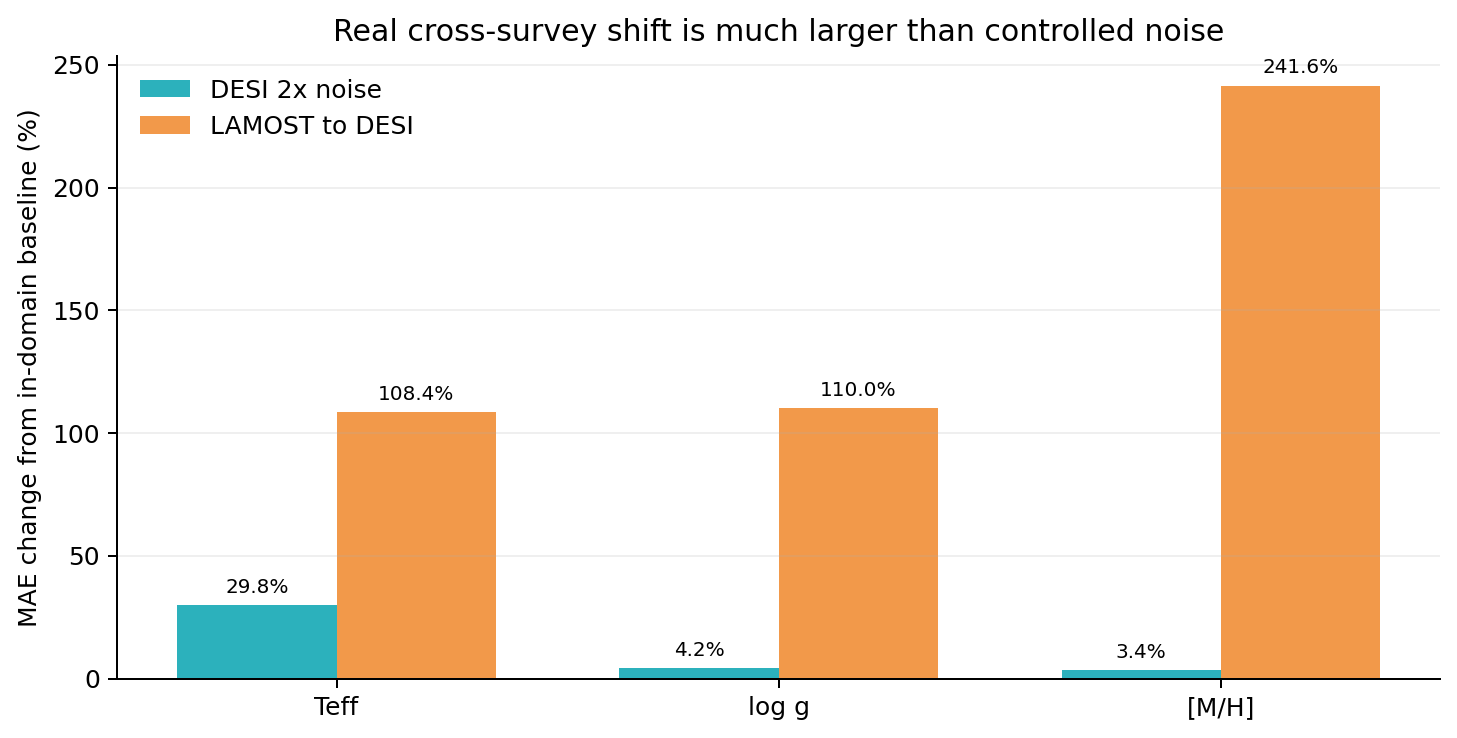

In [1]:
display(Image(filename=str(FIGURES / 'real_vs_controlled_shift.png')))


### Controlled DESI 2x-noise reference


In [1]:
noise_2x


target  clean_mae     mae  mae_change_percent  change_ci_lower  change_ci_upper
   feh      0.208   0.215               3.448           -1.626            9.607
  logg      0.216   0.226               4.195           -0.589           10.227
  teff    122.626 159.190              29.818           19.352           43.553


## Three-way adaptation comparison

CORAL uses target spectra without labels. Retraining uses only the disjoint
target-adaptation labels. The same 1,088 evaluation stars are used for every
method. CORAL is inconclusive for Teff/log g and detectably harms [M/H]; labeled
retraining improves all three targets.


In [1]:
method_metrics


                      method             target_access target     mae     r2  mae_change_vs_source_percent
                 source_only               source_only   teff 109.415  0.656                         0.000
                 source_only               source_only   logg   0.260  0.558                         0.000
                 source_only               source_only    feh   0.250  0.220                         0.000
             coral_unlabeled unlabeled_target_features   teff 113.453  0.645                         3.691
             coral_unlabeled unlabeled_target_features   logg   0.264  0.613                         1.596
             coral_unlabeled unlabeled_target_features    feh   0.393 -0.182                        57.548
source_plus_target_retrained            labeled_target   teff  78.397  0.799                       -28.349
source_plus_target_retrained            labeled_target   logg   0.153  0.847                       -40.931
source_plus_target_retrained         

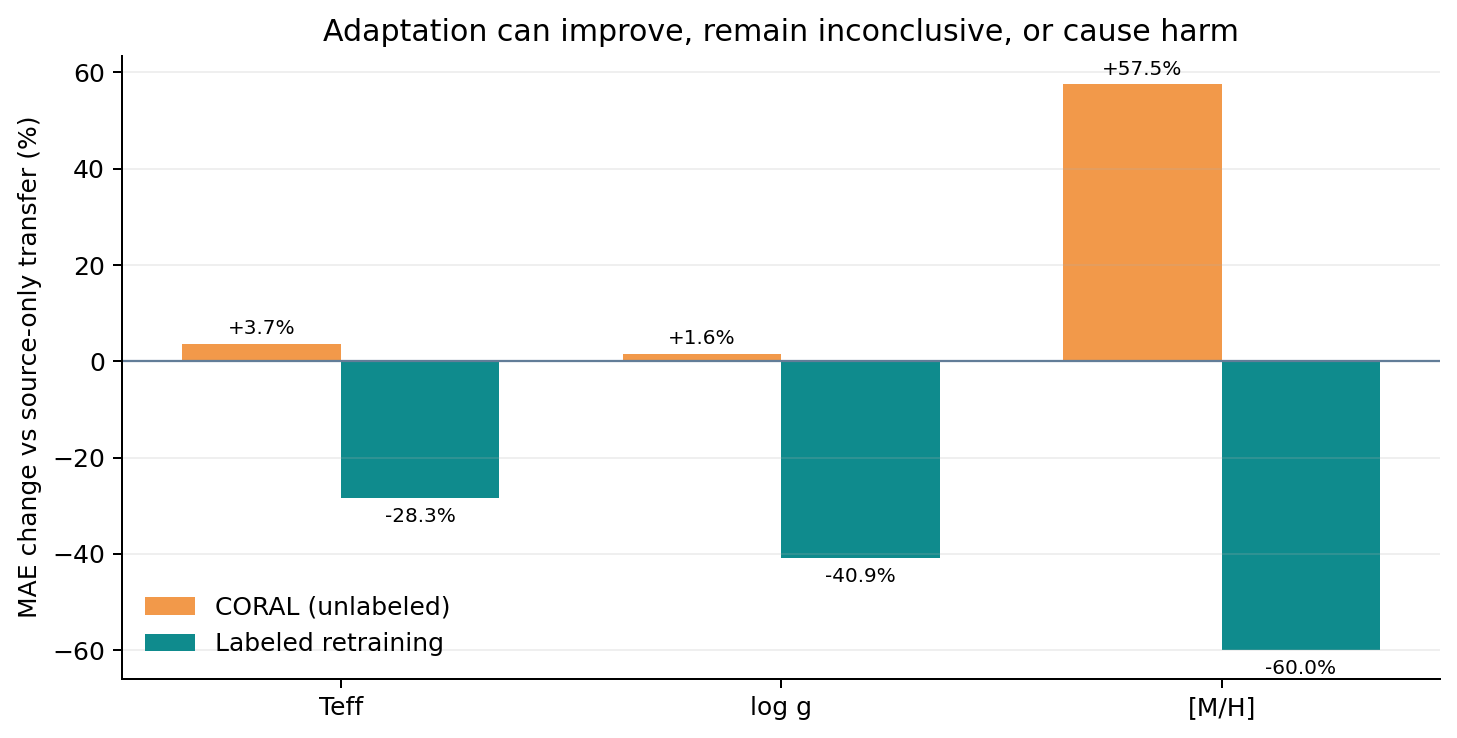

In [1]:
display(Image(filename=str(FIGURES / 'adaptation_relative_effects.png')))


### Paired same-star adaptation effects


In [1]:
paired_effects


                      method target  paired_mae_difference  paired_difference_ci_lower  paired_difference_ci_upper                  conclusion
             coral_unlabeled    feh                  0.144                       0.138                       0.149             detectable_harm
source_plus_target_retrained    feh                 -0.150                      -0.168                      -0.134      detectable_improvement
             coral_unlabeled   logg                  0.004                      -0.004                       0.013 inconclusive_not_equivalent
source_plus_target_retrained   logg                 -0.106                      -0.120                      -0.092      detectable_improvement
             coral_unlabeled   teff                  4.038                      -0.017                       7.941 inconclusive_not_equivalent
source_plus_target_retrained   teff                -31.018                     -34.916                     -27.235      detectable_improvement

## Calibration fails under real shift

Nominal 90% intervals calibrated on LAMOST under-cover on DESI. Recalibration
using the 467-star target-adaptation partition restores approximately nominal
coverage without touching target evaluation labels.


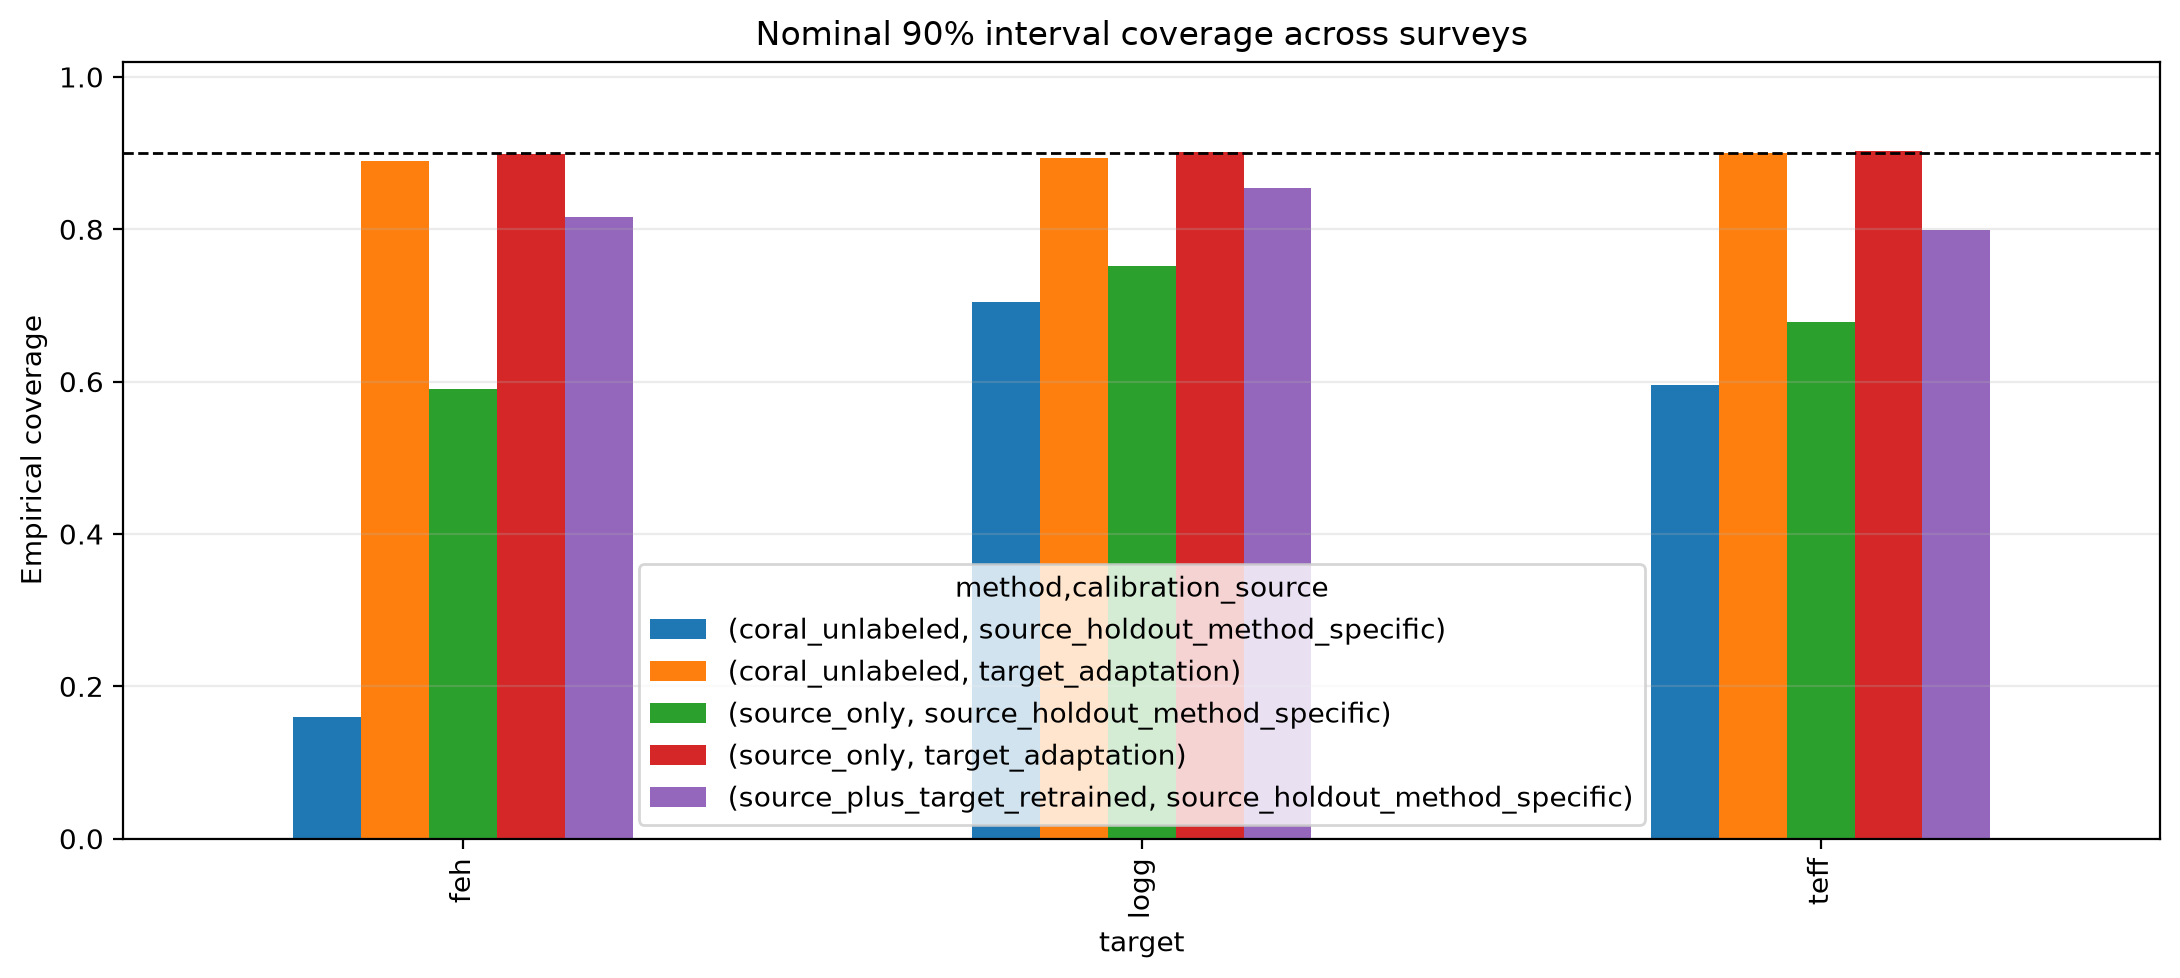

In [1]:
display(Image(filename=str(CROSS / 'calibration_cross_survey.png')))


In [1]:
calibration


                      method             calibration_source target  coverage  mean_width
                 source_only source_holdout_method_specific   teff     0.678     232.949
                 source_only source_holdout_method_specific   logg     0.752       0.587
                 source_only source_holdout_method_specific    feh     0.590       0.293
             coral_unlabeled source_holdout_method_specific   teff     0.596     222.341
             coral_unlabeled source_holdout_method_specific   logg     0.705       0.592
             coral_unlabeled source_holdout_method_specific    feh     0.160       0.276
source_plus_target_retrained source_holdout_method_specific   teff     0.800     223.943
source_plus_target_retrained source_holdout_method_specific   logg     0.855       0.547
source_plus_target_retrained source_holdout_method_specific    feh     0.816       0.314
                 source_only              target_adaptation   teff     0.903     484.959
                 sour

## Population support explains part, not all, of the loss

The full effect combines survey and population shift. A second analysis keeps
the 918 target stars jointly within source-training Teff/log g/[M/H] minima and
maxima. Degradation remains substantial.


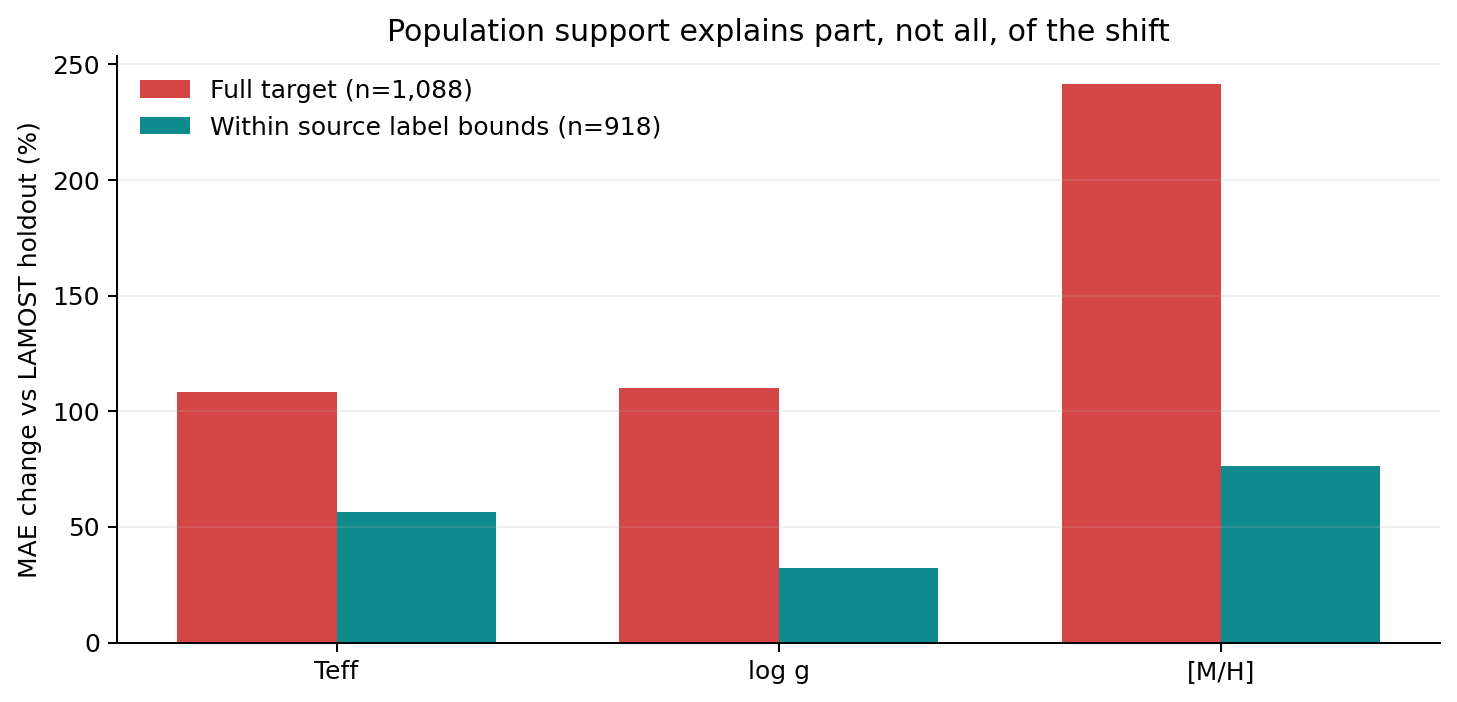

In [1]:
display(Image(filename=str(FIGURES / 'support_sensitivity.png')))


In [1]:
within_support


target  supported_stars  retained_fraction    mae    r2
   feh              918              0.844  0.129 0.659
  logg              918              0.844  0.163 0.793
  teff              918              0.844 82.032 0.754


## Target-label budgets: small samples can hurt

Ten repeated draws at each budget show that five labels raise median error for
all three targets. At 100 labels, median improvements appear across all targets.


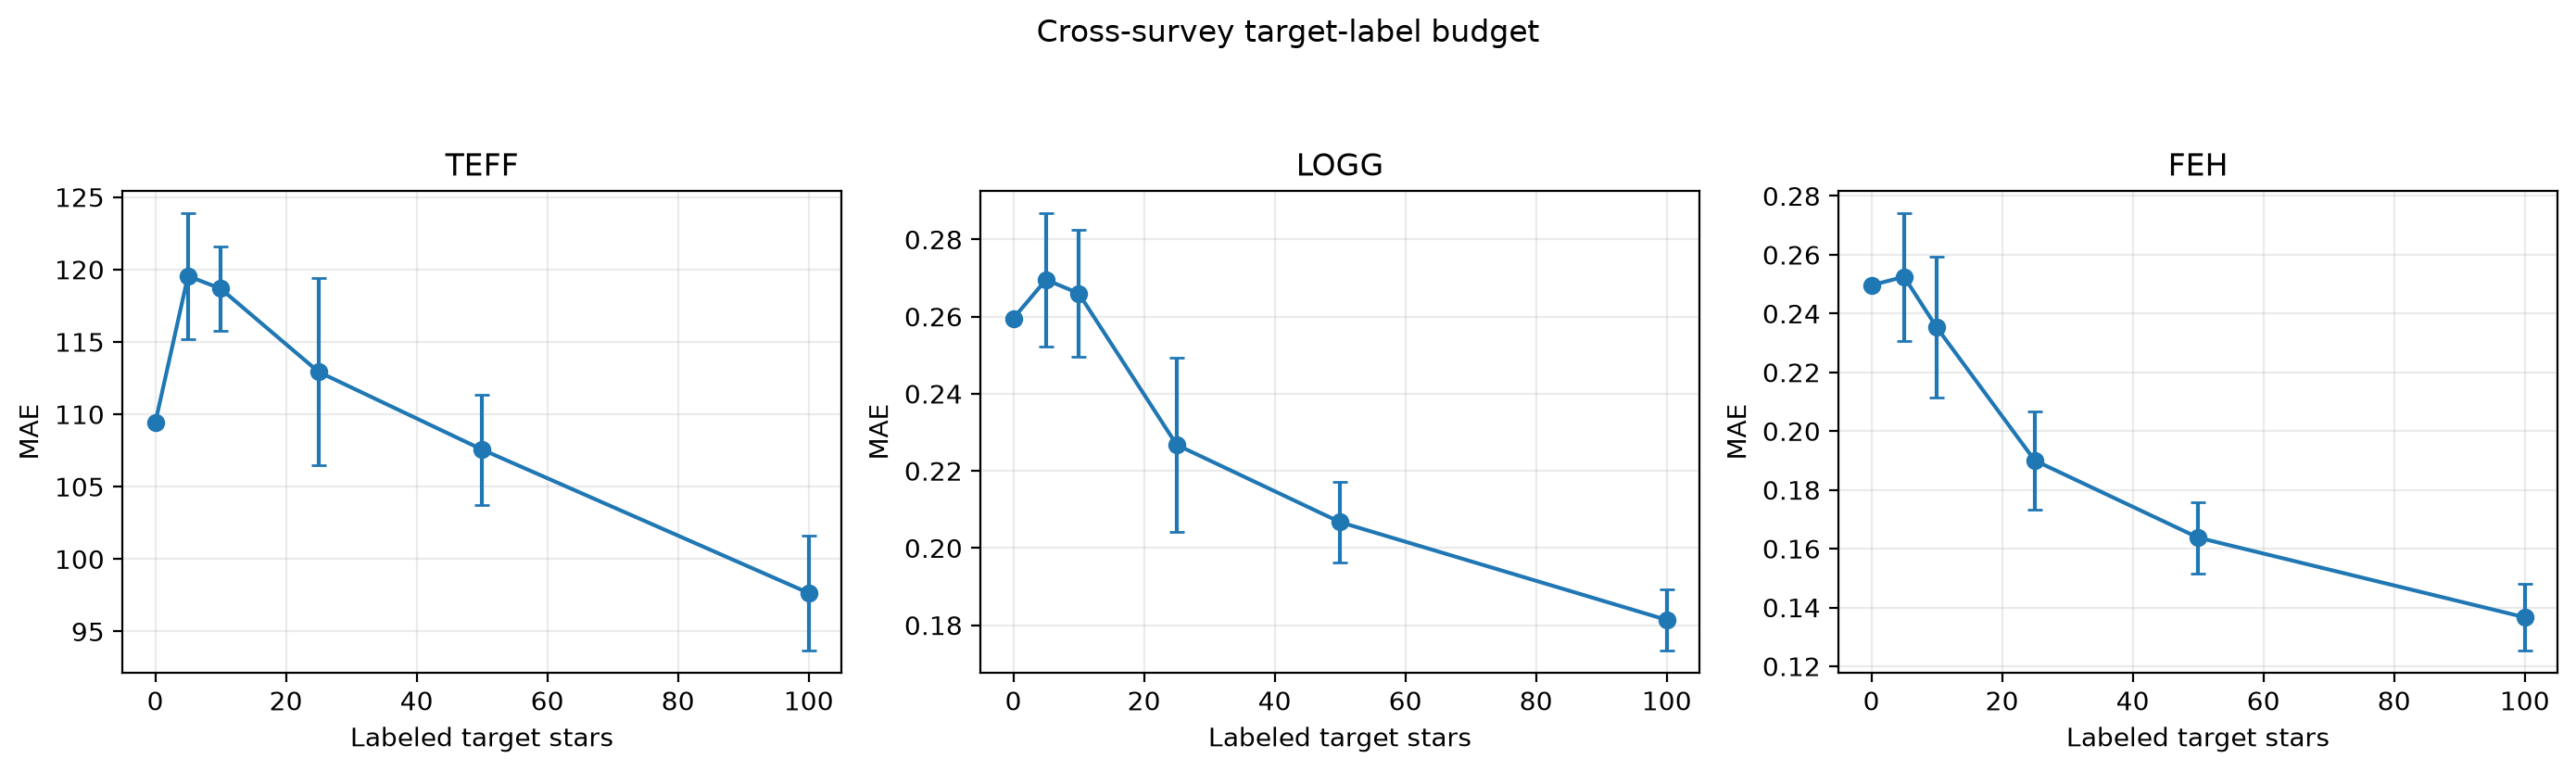

In [1]:
display(Image(filename=str(CROSS / 'label_budget.png')))


In [1]:
# Median MAE change (%) across ten random draws
label_budget_medians


target    feh   logg   teff
budget                     
0        0.00  -0.00   0.00
5        1.45   2.83   9.89
10      -5.50   4.56   8.41
25     -23.58 -14.39   1.50
50     -35.72 -19.68  -0.93
100    -46.04 -31.09 -11.55


## Formal APOGEE label-error sensitivity

The simulation perturbs labels by reported independent Gaussian formal errors
while preserving the same perturbed truth across methods. It does not validate
APOGEE or address shared pipeline systematics. Retraining remains better in all
replicates; CORAL [M/H] remains worse in all replicates.


In [1]:
reference_sensitivity


                      method target  sensitivity_difference_median  sensitivity_difference_ci_lower  sensitivity_difference_ci_upper  fraction_difference_below_zero
             coral_unlabeled    feh                          0.142                            0.136                            0.147                           0.000
                 source_only    feh                          0.000                            0.000                            0.000                           0.000
source_plus_target_retrained    feh                         -0.147                           -0.164                           -0.131                           1.000
             coral_unlabeled   logg                          0.002                           -0.007                            0.010                           0.342
                 source_only   logg                          0.000                            0.000                            0.000                           0.000
source_plu

## Model-family ablation


In [1]:
target_ablation


     family target     mae    r2  mae_change_vs_source_domain_percent
      ridge   teff  92.707 0.740                              175.279
      ridge   logg   0.200 0.727                              152.857
      ridge    feh   0.164 0.713                              339.455
extra_trees   teff 110.623 0.650                              109.688
extra_trees   logg   0.262 0.553                              110.615
extra_trees    feh   0.251 0.214                              244.254
        mlp   teff 130.330 0.538                              112.843
        mlp   logg   0.248 0.685                               78.483
        mlp    feh   0.185 0.679                              163.838


## Reproduce the benchmark

```bash
python -m pip install -e ".[dev,desi]"
python -m pytest -q

# Public acquisition and contract commands are documented in data/README.md
stellar-benchmark cross-survey-run --config configs/lamost_to_desi.yaml
```

The evidence bundle includes the exact configuration, acquisition manifest,
input hashes, prespecified quality gate, split manifest, per-star predictions,
calibration, paired effects, support sensitivity, label budgets, OOD/subgroup
tables, ablations, physical checks, report, and this notebook. Raw survey spectra
are not redistributed.

### Claim boundary

Supported: the frozen LAMOST DR2 to DESI DR1 transfer and reliability findings
on the common APOGEE DR12 scale. Not supported: independent APOGEE validation,
pure instrument causality, universal survey/population generalization, exact
line-spread modeling, B+R+Z fusion, or isochrone-manifold consistency.
